# Installs

In [1]:
!pip install autoviml
!pip install sklearn-genetic


     |████████████████████████████████| 125 kB 620 kB/s            
     |████████████████████████████████| 96 kB 1.8 MB/s            
     |████████████████████████████████| 125 kB 4.9 MB/s            
     |████████████████████████████████| 24.8 MB 635 kB/s            
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 0.23.2
    Uninstalling scikit-learn-0.23.2:
      Successfully uninstalled scikit-learn-0.23.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
yellowbrick 1.3.post1 requires numpy<1.20,>=1.16.0, but you have numpy 1.20.3 which is incompatible.
pdpbox 0.2.1 requires matplotlib==3.1.1, but you have matplotlib 3.5.1 which is incompatible.
hypertools 0.7.0 requires scikit-learn!=0.22,<0.24,>=0.19.1, but you have scikit-learn 1.0.2 which is incompatible.
featuretools 1.4.1 requires numpy>=1.21.0, but you have numpy 1

# Required Libraires

In [2]:
#imports
import pandas as pd
import numpy as np
from collections import defaultdict
from autoviml.Auto_ViML import Auto_ViML
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score
from sklearn.metrics import balanced_accuracy_score,mean_squared_error
from pprint import pprint
import seaborn as sns
import featuretools as ft
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn import model_selection
import pickle
import scipy
import statistics as stats
## Lasso search
from sklearn.model_selection import GridSearchCV,cross_val_score
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import statsmodels.api as sm
import statsmodels.formula.api as smf

## Gentic search
from genetic_selection import GeneticSelectionCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from sklearn.linear_model import SGDClassifier
### Hyperopt imports
from hyperopt import hp, tpe, fmin, Trials, STATUS_OK

### optuna imports
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import os

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score,cross_val_predict
from sklearn.metrics import confusion_matrix,precision_score,recall_score,f1_score



Imported Auto_ViML version: 0.1.684. Call using:
             m, feats, trainm, testm = Auto_ViML(train, target, test,
                            sample_submission='',
                            scoring_parameter='', KMeans_Featurizer=False,
                            hyper_param='RS',feature_reduction=True,
                             Boosting_Flag='CatBoost', Binning_Flag=False,
                            Add_Poly=0, Stacking_Flag=False,Imbalanced_Flag=False,
                            verbose=1)
            

Imported Auto_NLP version: 0.0.47.. Call using:
     train_nlp, test_nlp, nlp_pipeline, predictions = Auto_NLP(
                nlp_column, train, test, target, score_type='balanced_accuracy',
                modeltype='Classification',top_num_features=200, verbose=0,
                build_model=True)


# Pre-Processing

In [3]:
def preprocessing(data):
    processed_data = convert_categorical_to_numbers(data)
    processed_data = auto_data_impute(data)
    processed_data = scaling_data(data)
    print("Pre-Processing done")
    return processed_data


def convert_categorical_to_numbers(data,unique_val=10):
    """converts categorical object dtypes to numeric encoded format"""
    obj_df = data.select_dtypes(include=[object])
    unique_list = [f for f in obj_df.columns if obj_df[f].unique().shape[0]>=unique_val]
    obj_df_sel = obj_df.drop(columns=unique_list)
    for col in obj_df_sel.columns:
        data[col] = pd.factorize(data[col])[0]
    print("conversion successfull")
    return data

def auto_data_impute(data,get_rid_percent=2):
    for x,y in data.isnull().sum().items():
        percent = y/data.shape[0]
        if percent <= get_rid_percent/100:
            data[x]  = data[x].fillna(data[x].mean())
        else:
            print("removed column : ",x)
            data = data.drop([x],axis=1)
    print("Data imputation successfull")
    return data

def scaling_data(data):
    num_df = data.select_dtypes(include = [int,float])
    for i in num_df:
        data[i] = data[i]/data[i].max()
    print("scaling was successfull")
    return data

In [4]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [5]:
data = pd.read_csv("/kaggle/input/titanic/train.csv")
data.drop(['Name','Ticket','Cabin'],1,inplace = True)
data

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.00,1,0,7.25,S
1,2,1,1,female,38.00,1,0,71.28,C
2,3,1,3,female,26.00,0,0,7.92,S
3,4,1,1,female,35.00,1,0,53.10,S
4,5,0,3,male,35.00,0,0,8.05,S
...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.00,0,0,13.00,S
887,888,1,1,female,19.00,0,0,30.00,S
888,889,0,3,female,NaN,1,2,23.45,S
889,890,1,1,male,26.00,0,0,30.00,C


In [6]:
data = preprocessing(data)

conversion successfull
removed column :  Age
Data imputation successfull
scaling was successfull
Pre-Processing done


In [7]:
data

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0.00,0.00,1.00,0.00,0.28,0.12,0.00,0.01,0.00
1,0.00,1.00,0.33,1.00,0.47,0.12,0.00,0.14,0.50
2,0.00,1.00,1.00,1.00,0.33,0.00,0.00,0.02,0.00
3,0.00,1.00,0.33,1.00,0.44,0.12,0.00,0.10,0.00
4,0.01,0.00,1.00,0.00,0.44,0.00,0.00,0.02,0.00
...,...,...,...,...,...,...,...,...,...
886,1.00,0.00,0.67,0.00,0.34,0.00,0.00,0.03,0.00
887,1.00,1.00,0.33,1.00,0.24,0.00,0.00,0.06,0.00
888,1.00,0.00,1.00,1.00,NaN,0.12,0.33,0.05,0.00
889,1.00,1.00,0.33,0.00,0.33,0.00,0.00,0.06,0.50


# Generating Features

In [8]:
def generate_feat(eid,df,f):
    es = ft.EntitySet(id = eid)
    es.add_dataframe(dataframe_name = eid, dataframe = df, index = 'id')
    es.normalize_dataframe(base_dataframe_name=eid, new_dataframe_name=f, index = f)
    feature_matrix, feature_names = ft.dfs(entityset=es, 
    target_dataframe_name = eid, #,'Mean',Std','Count', 'Percent_True', 'Num_Unique', 'Trend', 'Skew'],
    max_depth = 4, 
    verbose = 1,n_jobs=-1)
    feature_matrix = feature_matrix.reindex(index=df['id'])
    return feature_matrix

def generate_features(data,target_ID):
    split_idx=data.shape[0]
    first_level_feat = list(data.columns)
    first_level_feat = [t for t in first_level_feat if target_ID!=t]
    first_level_feat  =first_level_feat[:]
    source = data.drop(target_ID,axis=1)
    source.reset_index(drop=True,inplace=True)
    target = data[[target_ID]]
    target.reset_index(drop=True,inplace=True)
    fmx = []
    for s in first_level_feat:
        out_ = generate_feat(target_ID,source,s)
        fmx.append(out_)
    feature_matrix = pd.concat(fmx,axis=1)
    original_ft_feat = list(feature_matrix.columns)
    feature_matrix = feature_matrix.loc[:,~feature_matrix.columns.duplicated()]
    target.reset_index(drop=True,inplace=True)
    target = target.reindex(index=source['id'])
    feature_matrix = pd.merge(feature_matrix,target,right_index=True,left_index=True)
    feature_matrix = auto_data_impute(feature_matrix,get_rid_percent=10)
    return feature_matrix
    

In [9]:
feature_matrix = generate_features(data,target_ID = 'Survived')
feature_matrix

Built 51 features
EntitySet scattered to 4 workers in 3 seconds
Elapsed: 00:01 | Progress: 100%|██████████
Built 51 features
EntitySet scattered to 4 workers in 3 seconds
Elapsed: 00:00 | Progress: 100%|██████████
Built 51 features
EntitySet scattered to 4 workers in 3 seconds
Elapsed: 00:00 | Progress: 100%|██████████
Built 51 features
EntitySet scattered to 4 workers in 3 seconds
Elapsed: 00:00 | Progress: 100%|██████████
Built 51 features
EntitySet scattered to 4 workers in 4 seconds
Elapsed: 00:00 | Progress: 100%|██████████
Built 51 features
EntitySet scattered to 4 workers in 3 seconds
Elapsed: 00:00 | Progress: 100%|██████████
Built 51 features
EntitySet scattered to 4 workers in 3 seconds
Elapsed: 00:00 | Progress: 100%|██████████
Built 51 features
EntitySet scattered to 4 workers in 3 seconds
Elapsed: 00:00 | Progress: 100%|██████████
removed column :  Age
removed column :  PassengerId.MAX(Survived.Age)
removed column :  PassengerId.MEAN(Survived.Age)
removed column :  Passeng

,PassengerId,Pclass,Sex,SibSp,Parch,Fare,Embarked,PassengerId.COUNT(Survived),PassengerId.MAX(Survived.Embarked),PassengerId.MAX(Survived.Fare),PassengerId.MAX(Survived.Parch),PassengerId.MAX(Survived.Pclass),PassengerId.MAX(Survived.Sex),PassengerId.MAX(Survived.SibSp),PassengerId.MEAN(Survived.Embarked),PassengerId.MEAN(Survived.Fare),PassengerId.MEAN(Survived.Parch),PassengerId.MEAN(Survived.Pclass),PassengerId.MEAN(Survived.Sex),PassengerId.MEAN(Survived.SibSp),PassengerId.MIN(Survived.Embarked),PassengerId.MIN(Survived.Fare),PassengerId.MIN(Survived.Parch),PassengerId.MIN(Survived.Pclass),PassengerId.MIN(Survived.Sex),PassengerId.MIN(Survived.SibSp),PassengerId.SUM(Survived.Age),PassengerId.SUM(Survived.Embarked),PassengerId.SUM(Survived.Fare),PassengerId.SUM(Survived.Parch),PassengerId.SUM(Survived.Pclass),PassengerId.SUM(Survived.Sex),PassengerId.SUM(Survived.SibSp),Pclass.COUNT(Survived),Pclass.MAX(Survived.Age),Pclass.MAX(Survived.Embarked),Pclass.MAX(Survived.Fare),Pclass.MAX(Survived.Parch),Pclass.MAX(Survived.PassengerId),Pclass.MAX(Survived.Sex),Pclass.MAX(Survived.SibSp),Pclass.MEAN(Survived.Age),Pclass.MEAN(Survived.Embarked),Pclass.MEAN(Survived.Fare),Pclass.MEAN(Survived.Parch),Pclass.MEAN(Survived.PassengerId),Pclass.MEAN(Survived.Sex),Pclass.MEAN(Survived.SibSp),Pclass.MIN(Survived.Age),Pclass.MIN(Survived.Embarked),...,Fare.SUM(Survived.Embarked),Fare.SUM(Survived.Parch),Fare.SUM(Survived.PassengerId),Fare.SUM(Survived.Pclass),Fare.SUM(Survived.Sex),Fare.SUM(Survived.SibSp),Embarked.COUNT(Survived),Embarked.MAX(Survived.Age),Embarked.MAX(Survived.Fare),Embarked.MAX(Survived.Parch),Embarked.MAX(Survived.PassengerId),Embarked.MAX(Survived.Pclass),Embarked.MAX(Survived.Sex),Embarked.MAX(Survived.SibSp),Embarked.MEAN(Survived.Age),Embarked.MEAN(Survived.Fare),Embarked.MEAN(Survived.Parch),Embarked.MEAN(Survived.PassengerId),Embarked.MEAN(Survived.Pclass),Embarked.MEAN(Survived.Sex),Embarked.MEAN(Survived.SibSp),Embarked.MIN(Survived.Age),Embarked.MIN(Survived.Fare),Embarked.MIN(Survived.Parch),Embarked.MIN(Survived.PassengerId),Embarked.MIN(Survived.Pclass),Embarked.MIN(Survived.Sex),Embarked.MIN(Survived.SibSp),Embarked.SKEW(Survived.Age),Embarked.SKEW(Survived.Fare),Embarked.SKEW(Survived.Parch),Embarked.SKEW(Survived.PassengerId),Embarked.SKEW(Survived.Pclass),Embarked.SKEW(Survived.Sex),Embarked.SKEW(Survived.SibSp),Embarked.STD(Survived.Age),Embarked.STD(Survived.Fare),Embarked.STD(Survived.Parch),Embarked.STD(Survived.PassengerId),Embarked.STD(Survived.Pclass),Embarked.STD(Survived.Sex),Embarked.STD(Survived.SibSp),Embarked.SUM(Survived.Age),Embarked.SUM(Survived.Fare),Embarked.SUM(Survived.Parch),Embarked.SUM(Survived.PassengerId),Embarked.SUM(Survived.Pclass),Embarked.SUM(Survived.Sex),Embarked.SUM(Survived.SibSp),Survived
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.00,1.00,0.00,0.12,0.00,0.01,0.00,1,0.00,0.01,0.00,1.00,0.00,0.12,0.00,0.01,0.00,1.00,0.00,0.12,0.00,0.01,0.00,1.00,0.00,0.12,0.28,0.00,0.01,0.00,1.00,0.00,0.12,491,0.93,1.00,0.14,1.00,1.00,1.00,1.00,0.31,0.21,0.03,0.07,0.49,0.29,0.08,0.01,0.00,...,0.00,0.00,5.19,13.00,1.00,0.12,644,1.00,0.51,1.00,1.00,1.00,1.00,1.00,0.37,0.05,0.07,0.50,0.78,0.32,0.07,0.01,0.00,0.00,0.00,0.33,0.00,0.00,0.37,3.65,2.65,-0.01,-0.71,0.80,3.54,0.18,0.07,0.14,0.29,0.26,0.46,0.15,203.91,34.04,44.33,324.91,504.67,203.00,46.00,0.00
1,0.00,0.33,1.00,0.12,0.00,0.14,0.50,1,0.50,0.14,0.00,0.33,1.00,0.12,0.50,0.14,0.00,0.33,1.00,0.12,0.50,0.14,0.00,0.33,1.00,0.12,0.47,0.50,0.14,0.00,0.33,1.00,0.12,216,1.00,1.00,1.00,0.67,1.00,1.00,0.38,0.48,0.20,0.16,0.06,0.52,0.44,0.05,0.01,-0.50,...,0.50,0.00,0.00,0.33,1.00,0.12,168,0.89,1.00,0.50,1.00,1.00,1.00,0.25,0.39,0.12,0.06,0.50,0.63,0.43,0.05,0.01,0.01,0.00,0.00,0.33,0.00,0.00,0.34,3.33,1.72,-0.01,0.23,0.27,1.09,0.19,0.16,0.11,0.29,0.31,0.50,0.07,50.07,19.66,10.17,83.97,105.67,73.00,8.12,1.00
2,0.00,1.00,1.00,0.00,0.00,0.02,0.00,1,0.00,0.02,0.00,1.00,1.00,0.00,0.00,

# Filtering data

In [10]:
def filter_data(feature_matrix,target_ID):
    lasso_feat = select_lasso_optu(feature_matrix,target_ID,objective,n_trials=50)
    lasso_feat  =[t for t in lasso_feat if t != target_ID]
    pearson_feat = select_pearson_feat(feature_matrix,target_ID,thr=0.05) #pearson
    pearson_feat  =[t for t in pearson_feat if t != target_ID]
    lasso_pearson_feats = list(set(pearson_feat).intersection(set(lasso_feat)))
    feats = lasso_pearson_feats+[target_ID]
    return feats

def objective(trial):
    alpha = trial.suggest_uniform('alpha',0.0,2.0)
    X,y,_ = get_data(feature_matrix)
    lasso_model = Lasso(alpha=alpha)
    acc = cross_val_score(lasso_model,X , y,scoring='r2',cv=5).mean()
    acc = -acc
    return acc

def select_lasso_optu(feature_matrix,target_id,objective,n_trials=20):
    X,y,cols = get_data(feature_matrix)
    study = optuna.create_study(direction='minimize')
    study.optimize(objective,n_trials=n_trials)
    lasso_model = Lasso(**study.best_params)
    lasso_model.fit(X,y)
    coeff = np.abs(lasso_model.coef_)
    feats = np.array(cols)[coeff>0].tolist()
    feats = feats+[target_ID]
    return feats

def select_genetic_feat(feature_matrix,target_ID,f_count):
    estimator = DecisionTreeClassifier()
    X,y = feature_matrix.drop(labels=[target_ID],axis=1),feature_matrix[target_ID]
    model = GeneticSelectionCV(
        estimator, cv=5, verbose=0,
        scoring="accuracy", max_features=f_count,
        n_population=100, crossover_proba=0.5,
        mutation_proba=0.2, n_generations=50,
        crossover_independent_proba=0.5,
        mutation_independent_proba=0.04,
        tournament_size=3, n_gen_no_change=10,
        caching=True, n_jobs=-1)

    model = model.fit(X, y)
#     print('Features:', X.columns[model.support_])
    feats = list(X.columns[model.support_])+[target_ID]
    return feats


def get_data(feature_matrix):
    sc = StandardScaler()
    X,y = feature_matrix.drop(labels=[target_ID],axis=1),feature_matrix[target_ID]
    cols = X.columns
    X = sc.fit_transform(X)
    return X,y,cols


def select_pearson_feat(feature_matrix,ID,thr=0.15):
    cols =[]
    for t in feature_matrix.columns:
        try:
            corr,_ = pearsonr(feature_matrix[ID],feature_matrix[t])
            if corr > thr:
                print(corr,t)
                cols.append(t)
        except:
            pass
    return cols

In [11]:
target_ID = "Survived"
feats = filter_data(feature_matrix,target_ID)
feats

0.5433513806577556 Sex
0.08162940708348347 Parch
0.2573065223849624 Fare
0.10184881923179398 Embarked
0.10184881923179398 PassengerId.MAX(Survived.Embarked)
0.2573065223849624 PassengerId.MAX(Survived.Fare)
0.08162940708348347 PassengerId.MAX(Survived.Parch)
0.5433513806577556 PassengerId.MAX(Survived.Sex)
0.10184881923179398 PassengerId.MEAN(Survived.Embarked)
0.2573065223849624 PassengerId.MEAN(Survived.Fare)
0.08162940708348347 PassengerId.MEAN(Survived.Parch)
0.5433513806577556 PassengerId.MEAN(Survived.Sex)
0.10184881923179398 PassengerId.MIN(Survived.Embarked)
0.2573065223849624 PassengerId.MIN(Survived.Fare)
0.08162940708348347 PassengerId.MIN(Survived.Parch)
0.5433513806577556 PassengerId.MIN(Survived.Sex)
0.10184881923179398 PassengerId.SUM(Survived.Embarked)
0.2573065223849624 PassengerId.SUM(Survived.Fare)
0.08162940708348347 PassengerId.SUM(Survived.Parch)
0.5433513806577556 PassengerId.SUM(Survived.Sex)
0.1711979613529339 Pclass.MAX(Survived.Age)
0.28737984219755247 Pclass

['Fare.MEAN(Survived.PassengerId)',
 'PassengerId.MIN(Survived.Fare)',
 'Parch.SKEW(Survived.Pclass)',
 'PassengerId.MEAN(Survived.Sex)',
 'Fare',
 'Fare.MIN(Survived.Sex)',
 'PassengerId.MAX(Survived.Fare)',
 'Sex',
 'SibSp.MAX(Survived.Embarked)',
 'PassengerId.MIN(Survived.Sex)',
 'Pclass.STD(Survived.Sex)',
 'Sex.STD(Survived.SibSp)',
 'Sex.MAX(Survived.Parch)',
 'Sex.MEAN(Survived.Parch)',
 'PassengerId.SUM(Survived.Sex)',
 'PassengerId.MAX(Survived.Sex)',
 'PassengerId.SUM(Survived.Fare)',
 'PassengerId.MEAN(Survived.Fare)',
 'SibSp.MAX(Survived.Parch)',
 'Sex.MEAN(Survived.Embarked)',
 'Age.SUM(Survived.SibSp)',
 'Survived']

In [12]:
feature_matrix[feats]

,Fare.MEAN(Survived.PassengerId),PassengerId.MIN(Survived.Fare),Parch.SKEW(Survived.Pclass),PassengerId.MEAN(Survived.Sex),Fare,Fare.MIN(Survived.Sex),PassengerId.MAX(Survived.Fare),Sex,SibSp.MAX(Survived.Embarked),PassengerId.MIN(Survived.Sex),Pclass.STD(Survived.Sex),Sex.STD(Survived.SibSp),Sex.MAX(Survived.Parch),Sex.MEAN(Survived.Parch),PassengerId.SUM(Survived.Sex),PassengerId.MAX(Survived.Sex),PassengerId.SUM(Survived.Fare),PassengerId.MEAN(Survived.Fare),SibSp.MAX(Survived.Parch),Sex.MEAN(Survived.Embarked),Age.SUM(Survived.SibSp),Survived
id,,,,,,,,,,,,,,,,,,,,,,
0,0.40,0.01,-0.66,0.00,0.01,0.00,0.01,0.00,1.00,0.00,0.46,0.13,0.83,0.04,0.00,0.00,0.01,0.01,1.00,0.15,0.50,0.00
1,0.00,0.14,-0.66,1.00,0.14,1.00,0.14,1.00,1.00,1.00,0.50,0.14,1.00,0.11,1.00,1.00,0.14,0.14,1.00,0.23,0.38,1.00
2,0.49,0.02,-0.66,1.00,0.02,0.00,0.02,1.00,1.00,1.00,0.46,0.14,1.00,0.11,1.00,1.00,0.02,0.02,0.83,0.23,0.88,1.00
3,0.54,0.10,-0.66,1.00,0.10,0.00,0.10,1.00,1.00,1.00,0.50,0.14,1.00,0.11,1.00,1.00,0.10,0.10,1.00,0.23,0.62,1.00
4,0.42,0.02,-0.66,0.00,0.02,0.00,0.02,0.00,1.00,0.00,0.46,0.13,0.83,0.04,0.00,0.00,0.02,0.02,0.83,0.15,0.62,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0.52,0.03,-0.66,0.00,0.03,0.00,0.03,0.00,1.00,0.00,0.49,0.13,0.83,0.04,0.00,0.00,0.03,0.03,0.83,0.15,0.50,0.00
887,0.84,0.06,-0.66,1.00,0.06,0.00,0.06,1.00,1.00,1.00,0.50,0.14,1.00,0.11,1.00,1.00,0.06,0.06,0.83,0.23,1.00,1.00
888,0.94,0.05,-0.57,1.00,0.05,0.00,0.05,1.00,1.00,1.00,0.46,0.14,1.00,0.11,1.00,1.00,0.05,0.05,1.00,0.23,0.00,0.00


# Machine Learning Models

In [13]:
x = feature_matrix[feats]
y = feature_matrix['Survived']
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state = 1,test_size = 0.25)

<h3> Logistic Regression

In [14]:
clf1 = LogisticRegression(C=.1)
clf1.fit(x_train,y_train)

LogisticRegression(C=0.1)

In [15]:
# Model Performance
y_train_pred = cross_val_predict(clf1,x_train,y_train,cv=4)
print("Confusion Matrix: \n",confusion_matrix(y_train,y_train_pred))
print('Precision Score:',precision_score(y_train,y_train_pred))
print("Recall Score:",recall_score(y_train,y_train_pred))
print("Accuracy Score:",accuracy_score(y_train,y_train_pred))
print("Cross Val Score Insample",cross_val_score(clf1,x_train,y_train,cv=4,scoring='accuracy').mean())
print("Cross Val Score Outsample",cross_val_score(clf1,x_test,y_test,cv=4,scoring='accuracy').mean())

Confusion Matrix: 
 [[421   0]
 [  0 247]]
Precision Score: 1.0
Recall Score: 1.0
Accuracy Score: 1.0
Cross Val Score Insample 1.0
Cross Val Score Outsample 0.9910714285714286


<h3>SGD Classifier

In [16]:
clf2 = SGDClassifier()
clf2.fit(x_train,y_train)

SGDClassifier()

In [17]:
# Model Performance
y_train_pred = cross_val_predict(clf2,x_train,y_train,cv=4)
print("Confusion Matrix: \n",confusion_matrix(y_train,y_train_pred))
print('Precision Score:',precision_score(y_train,y_train_pred))
print("Recall Score:",recall_score(y_train,y_train_pred))
print("Accuracy Score:",accuracy_score(y_train,y_train_pred))
print("Cross Val Score Insample",cross_val_score(clf2,x_train,y_train,cv=4,scoring='accuracy').mean())
print("Cross Val Score Outsample",cross_val_score(clf2,x_test,y_test,cv=4,scoring='accuracy').mean())

Confusion Matrix: 
 [[421   0]
 [  0 247]]
Precision Score: 1.0
Recall Score: 1.0
Accuracy Score: 1.0
Cross Val Score Insample 0.9760479041916168
Cross Val Score Outsample 1.0


In [18]:
clf3 = DecisionTreeClassifier(max_depth=4,min_samples_split=2)
clf3.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=4)

In [19]:
# Model Performance
y_train_pred = cross_val_predict(clf3,x_train,y_train,cv=4)
print("Confusion Matrix: \n",confusion_matrix(y_train,y_train_pred))
print('Precision Score:',precision_score(y_train,y_train_pred))
print("Recall Score:",recall_score(y_train,y_train_pred))
print("Accuracy Score:",accuracy_score(y_train,y_train_pred))
print("Cross Val Score Insample",cross_val_score(clf3,x_train,y_train,cv=4,scoring='accuracy').mean())
print("Cross Val Score Outsample",cross_val_score(clf3,x_test,y_test,cv=4,scoring='accuracy').mean())

Confusion Matrix: 
 [[421   0]
 [  0 247]]
Precision Score: 1.0
Recall Score: 1.0
Accuracy Score: 1.0
Cross Val Score Insample 1.0
Cross Val Score Outsample 1.0


<h3>AutoViml

##############  D A T A   S E T  A N A L Y S I S  #######################
Training Set Shape = (668, 22)
    Training Set Memory Usage = 0.12 MB
Test Set Shape = (223, 22)
    Test Set Memory Usage = 0.04 MB
Single_Label Target: ['Survived']

################ Binary_Classification VISUALIZATION Started #####################
Random shuffling the data set before training
    Using HyperOpt which is approximately 3X Faster than GridSearchCV but results vary...
       Class  -> Counts -> Percent
         0.0:     421  ->   63.0%
         1.0:     247  ->   37.0%
    Target Survived is already numeric. No transformation done.
############## C L A S S I F Y I N G  V A R I A B L E S  ####################
Classifying variables in data set...
    21 Predictors classified...
        This does not include the Target column(s)
    No variables removed since no ID or low-information variables found in data set
Number of Processors on this device = 1
CPU available
    No GPU active on this device
##

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Learning rate set to 0.017328
0:	learn: 0.8036606	test: 0.7761194	best: 0.7761194 (0)	total: 56.9ms	remaining: 2m 50s


500:	learn: 0.9134775	test: 0.8507463	best: 0.8507463 (278)	total: 442ms	remaining: 2.21s
1000:	learn: 0.9484193	test: 0.8208955	best: 0.8507463 (278)	total: 808ms	remaining: 1.61s
1500:	learn: 0.9667221	test: 0.7910448	best: 0.8507463 (278)	total: 1.18s	remaining: 1.18s
2000:	learn: 0.9733777	test: 0.8059701	best: 0.8507463 (278)	total: 1.53s	remaining: 763ms
Stopped by overfitting detector  (2000 iterations wait)

bestTest = 0.8507462687
bestIteration = 278

Shrink model to first 279 iterations.
    Actual training time (in seconds): 2
###########  Single_Label  M O D E L   R E S U L T S #################
5-fold Cross Validation logloss = 0.8507462686567164
    CatBoost Best Parameters for Model: Iterations = 278, learning_rate = 0.02
Finding Best Threshold for Highest F1 Score...
    Using threshold=0.5. However, 0.386 provides better F1=0.81 for rare class...
########################################################
CatBoost Model Prediction Results on Held Out CV Data Set:
    Regu

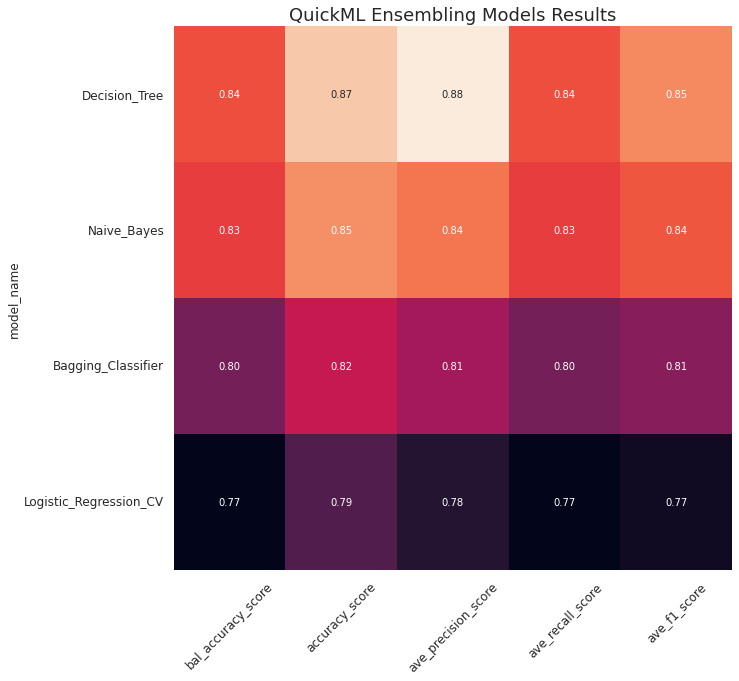

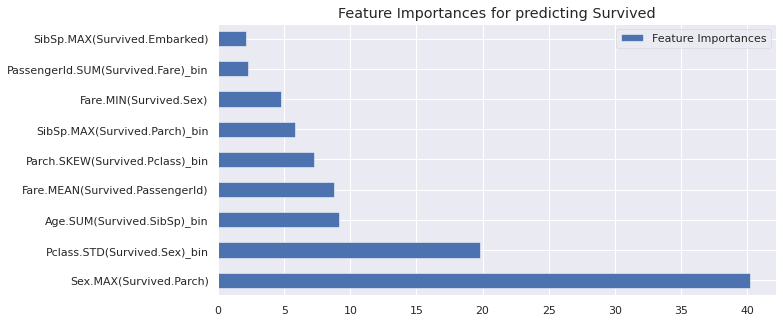

In [20]:
feature_matrix = feature_matrix[feats]
sample_submission = ''
scoring_parameter = 'log_loss'
m,feats,trainm,testm = Auto_ViML(x_train,target_ID,x_test,sample_submission
                                ,scoring_parameter = scoring_parameter,hyper_param = 'HO',feature_reduction = True,Boosting_Flag = 'catboost',Binning_Flag ='False',Add_Poly = False)